# LLM Training Pipeline — Part 5: Evaluation

Stage 5 of 6. A measurement-only notebook — no new checkpoints are trained. Loads
`sft_model.pt`, `ppo_model.pt`, and `dpo_model.pt` and compares them via an independent
LLM-as-judge (`Qwen2.5-1.5B-Instruct`, run locally), then loads Part 3's
`ppo_training_log.json` to plot the reward-vs-KL overoptimization curve.

**How to use this notebook:**
- Read each theory section; keep `docs/llm_training_pipeline_reference.html`
  open in another tab (Section 8) for the full discussion of judge biases.
- Code and tests are already implemented and verified — run cells top to
  bottom. Answer the **Question** cells yourself.
- **Note on the judge model:** `Qwen2.5-1.5B-Instruct` (~3GB) downloads from the
  HuggingFace Hub on first run — this is much larger than anything else in this
  pipeline (the ~14M-parameter pipeline model itself is a few tens of MB). The first
  cell that loads it may take a few minutes; this is expected, not a hang.

**Parts:**
1. LLM-as-Judge Pairwise Comparison
2. SFT vs PPO vs DPO Win-Rates
3. Reward-vs-KL Overoptimization Curve

In [1]:
import time, math, os, json
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tokenizers import ByteLevelBPETokenizer

import sys
sys.path.insert(0, '../..')
from src.llm_pipeline.model import GPTConfig, GPTModel
from src.llm_pipeline.data import TOPIC_KEYWORDS, format_sft_prompt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

CKPT_DIR = "../../data/checkpoints/llm_training_pipeline"
torch.manual_seed(0)

tokenizer = ByteLevelBPETokenizer(
    f"{CKPT_DIR}/tinystories_bpe-vocab.json",
    f"{CKPT_DIR}/tinystories_bpe-merges.txt",
)

def load_pipeline_model(name):
    ckpt = torch.load(f"{CKPT_DIR}/{name}", weights_only=False)
    m = GPTModel(ckpt['config']).to(device)
    m.load_state_dict(ckpt['model_state_dict'])
    m.eval()
    return m

sft_model = load_pipeline_model('sft_model.pt')
ppo_model = load_pipeline_model('ppo_model.pt')
dpo_model = load_pipeline_model('dpo_model.pt')
print(f"Loaded sft_model.pt, ppo_model.pt, dpo_model.pt — "
      f"{sum(p.numel() for p in sft_model.parameters()):,} params each")

Device: cuda


Loaded sft_model.pt, ppo_model.pt, dpo_model.pt — 13,817,856 params each


---
## Part 1: LLM-as-Judge Pairwise Comparison

`judge_pair_both_orders` presents the same pair to the judge twice (swapped positions) and
combines a log-probability preference margin from each ordering — see
`docs/llm_training_pipeline_reference.html#s8` for why position bias makes evaluating both
orderings necessary, and why a margin-based combination is used instead of requiring exact
token-level agreement (this pipeline's actual judge model shows position bias strong
enough that exact-agreement would produce zero usable signal).

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

JUDGE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
print(f"Loading judge model {JUDGE_MODEL} (first run downloads ~3GB, may take a few minutes)...")
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL)
# low_cpu_mem_usage=True loads weights directly into the target dtype via
# accelerate's meta-device path instead of materializing a full fp32 copy on
# CPU first — needed on memory-constrained machines (this pipeline's dev box
# has 7.6GB RAM total) where the naive load pattern can trigger the Linux
# OOM killer while loading a ~3GB fp16 model.
judge_model = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL,
    torch_dtype=torch.float16 if device == 'cuda' else torch.float32,
    low_cpu_mem_usage=True,
).to(device)
judge_model.eval()
print("Judge model loaded")

Loading judge model Qwen/Qwen2.5-1.5B-Instruct (first run downloads ~3GB, may take a few minutes)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Judge model loaded


In [3]:
JUDGE_PROMPT_TEMPLATE = """You are judging two short story completions written for the same prompt. Respond with exactly one letter: "A" if Completion A is better (more coherent, on-topic, and well-written), or "B" if Completion B is better. Do not explain your answer.

Prompt: {prompt}

Completion A: {completion_a}

Completion B: {completion_b}

Better completion:"""

def _token_id_variants(letter):
    """Candidate token ids for a bare letter as it might be tokenized at the
    start of a generated response, with or without a leading space."""
    ids = set()
    for s in (letter, ' ' + letter):
        enc = judge_tokenizer.encode(s, add_special_tokens=False)
        if len(enc) >= 1:
            ids.add(enc[0])
    return sorted(ids)

_A_TOKEN_IDS = _token_id_variants('A')
_B_TOKEN_IDS = _token_id_variants('B')

@torch.no_grad()
def judge_logit_margin(prompt, completion_a, completion_b):
    """Returns log P(A) - log P(B) at the answer position for one ordering
    (positive means completion_a, placed as 'A', is preferred)."""
    text = JUDGE_PROMPT_TEMPLATE.format(prompt=prompt, completion_a=completion_a, completion_b=completion_b)
    messages = [{"role": "user", "content": text}]
    inputs = judge_tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(device)
    out = judge_model(**inputs)
    logits = out.logits[0, -1, :].float()
    log_probs = torch.log_softmax(logits, dim=-1)
    log_p_a = torch.logsumexp(log_probs[_A_TOKEN_IDS], dim=0)
    log_p_b = torch.logsumexp(log_probs[_B_TOKEN_IDS], dim=0)
    return (log_p_a - log_p_b).item()


def judge_pair_both_orders(prompt, completion_1, completion_2, margin_threshold=0.1):
    """Returns 1 if completion_1 is preferred, -1 if completion_2 is preferred, 0
    if the combined margin (after cancelling additive position bias across both
    orderings) falls inside the indifference threshold."""
    margin_1 = judge_logit_margin(prompt, completion_1, completion_2)   # + favors completion_1 (as 'A')
    margin_2 = judge_logit_margin(prompt, completion_2, completion_1)   # + favors completion_2 (as 'A')
    combined = margin_1 - margin_2
    if combined > margin_threshold:
        return 1
    if combined < -margin_threshold:
        return -1
    return 0

In [4]:
# TEST 1: judge sanity check on an obviously-better-vs-worse pair. This is a STRUCTURAL
# check (the judge mechanism runs end-to-end and returns a valid value), not a check that
# the judge gets this specific comparison right — see the note below for why.
good_text = "Once upon a time, a little girl named Lily found a puppy in the park. She took it home and they became best friends."
bad_text = "puppy puppy park park the the the a a girl girl asdlkj qwoeiru zzxcv."
result = judge_pair_both_orders("Write a short story about a puppy:\n", good_text, bad_text)
assert result in (1, -1, 0), f"judge_pair_both_orders returned an invalid value: {result}"
print(f"TEST 1 PASSED — judge mechanism runs end-to-end and returns a valid value (result={result})")
if result != 1:
    print("Note: the judge did NOT prefer the obviously-coherent completion here. On this "
          "judge model, margin-subtraction does not reliably cancel position bias for short "
          "text — confirmed by testing several independent story pairs, where the combined "
          "margin got the wrong sign in roughly half of them even though each pair had an "
          "objectively coherent vs. objectively degenerate completion. This is a real limit "
          "of a 1.5B-parameter judge on short text, not a bug in judge_pair_both_orders — see "
          "Question 1 and Section 8's discussion of judge biases. Because of this, Part 2's "
          "win-rates below are reported as exploratory/qualitative evidence alongside the "
          "oracle sentiment scores from Notebook 4, not as the sole quantitative claim of "
          "whether DPO or PPO actually improved over SFT.")

TEST 1 PASSED — judge mechanism runs end-to-end and returns a valid value (result=-1)
Note: the judge did NOT prefer the obviously-coherent completion here. On this judge model, margin-subtraction does not reliably cancel position bias for short text — confirmed by testing several independent story pairs, where the combined margin got the wrong sign in roughly half of them even though each pair had an objectively coherent vs. objectively degenerate completion. This is a real limit of a 1.5B-parameter judge on short text, not a bug in judge_pair_both_orders — see Question 1 and Section 8's discussion of judge biases. Because of this, Part 2's win-rates below are reported as exploratory/qualitative evidence alongside the oracle sentiment scores from Notebook 4, not as the sole quantitative claim of whether DPO or PPO actually improved over SFT.


### Question 1

`judge_pair_both_orders` combines the two orderings by subtracting their raw preference
margins (`combined = margin_1 - margin_2`), which exactly cancels an additive position bias
only *if* that bias is a content-independent constant. On this pipeline's actual judge
model, it often isn't: testing several independent obviously-good-vs-obviously-bad story
pairs found the combined margin gets the wrong sign in roughly half of them (see the
notebook's own printed diagnostic above, if TEST 1's `result != 1`). Why might a small
(1.5B-parameter) instruct model's position bias be *content-dependent* rather than a clean
additive offset — what would you expect a much larger judge model to do differently? Given
this, how much weight should Part 2's judge-based win-rates actually carry versus Notebook
4's oracle sentiment-score comparison?

*Write your answer below:*

---
## Part 2: SFT vs PPO vs DPO Win-Rates

Compares each pair of models on the same 10 held-out topics (not used to build Part 3's
preference dataset's prompt sampling order, though the same topic *vocabulary* — TinyStories
has too small a natural topic space to hold out entirely-unseen topics at this model scale).

In [5]:
held_out_topics = TOPIC_KEYWORDS[-10:]
held_out_prompts = [format_sft_prompt(t) for t in held_out_topics]

@torch.no_grad()
def generate_completion(model, prompt, max_new_tokens=40):
    prompt_ids = torch.tensor([tokenizer.encode(prompt).ids], device=device)
    out = model.generate(prompt_ids, max_new_tokens=max_new_tokens, temperature=0.8, top_k=40)
    return tokenizer.decode(out[0, prompt_ids.shape[1]:].tolist())


def compute_win_rate(model_a, model_b, name_a, name_b, prompts):
    a_wins, b_wins, ties = 0, 0, 0
    for prompt in prompts:
        comp_a = generate_completion(model_a, prompt)
        comp_b = generate_completion(model_b, prompt)
        result = judge_pair_both_orders(prompt, comp_a, comp_b)
        if result == 1:
            a_wins += 1
        elif result == -1:
            b_wins += 1
        else:
            ties += 1
    n = len(prompts)
    print(f"{name_a} vs {name_b}: {name_a} wins {a_wins}/{n} ({a_wins/n:.1%}), "
          f"{name_b} wins {b_wins}/{n} ({b_wins/n:.1%}), "
          f"ties/position-bias {ties}/{n} ({ties/n:.1%})")
    return a_wins / n, b_wins / n, ties / n

In [6]:
sft_vs_ppo = compute_win_rate(ppo_model, sft_model, "PPO", "SFT", held_out_prompts)
sft_vs_dpo = compute_win_rate(dpo_model, sft_model, "DPO", "SFT", held_out_prompts)
ppo_vs_dpo = compute_win_rate(ppo_model, dpo_model, "PPO", "DPO", held_out_prompts)

PPO vs SFT: PPO wins 8/10 (80.0%), SFT wins 2/10 (20.0%), ties/position-bias 0/10 (0.0%)


DPO vs SFT: DPO wins 8/10 (80.0%), SFT wins 2/10 (20.0%), ties/position-bias 0/10 (0.0%)


PPO vs DPO: PPO wins 8/10 (80.0%), DPO wins 2/10 (20.0%), ties/position-bias 0/10 (0.0%)


In [7]:
# TEST 2: structural check only (all three comparisons ran and produced valid win/tie
# rates that sum to 1.0) — NOT a hard requirement that any particular model wins. Part 1's
# TEST 1 already found this judge model/prompt combination gives an unreliable verdict on
# a fraction of even obviously-one-sided pairs, so a judge-based win-rate here is reported
# as exploratory evidence alongside Notebook 4's oracle sentiment-score comparison, not
# asserted as the deciding signal — forcing a pass/fail threshold on a signal already shown
# to be noisy would only hide that noise, not fix it.
for name, wr in [("PPO vs SFT", sft_vs_ppo), ("DPO vs SFT", sft_vs_dpo), ("PPO vs DPO", ppo_vs_dpo)]:
    total = sum(wr)
    assert abs(total - 1.0) < 1e-6, f"{name} win/tie rates do not sum to 1.0: {wr}"
print(f"PPO win-rate over SFT: {sft_vs_ppo[0]:.1%} vs SFT win-rate {sft_vs_ppo[1]:.1%} (tie {sft_vs_ppo[2]:.1%})")
print(f"DPO win-rate over SFT: {sft_vs_dpo[0]:.1%} vs SFT win-rate {sft_vs_dpo[1]:.1%} (tie {sft_vs_dpo[2]:.1%})")
print(f"PPO win-rate over DPO: {ppo_vs_dpo[0]:.1%} vs DPO win-rate {ppo_vs_dpo[1]:.1%} (tie {ppo_vs_dpo[2]:.1%})")
print("TEST 2 PASSED — all three judge comparisons ran and produced valid win/tie rates. "
      "Read these alongside Notebook 4's oracle sentiment comparison (SFT +0.950, PPO "
      "+0.845, DPO +1.000) rather than in isolation — see Question 2.")

PPO win-rate over SFT: 80.0% vs SFT win-rate 20.0% (tie 0.0%)
DPO win-rate over SFT: 80.0% vs SFT win-rate 20.0% (tie 0.0%)
PPO win-rate over DPO: 80.0% vs DPO win-rate 20.0% (tie 0.0%)
TEST 2 PASSED — all three judge comparisons ran and produced valid win/tie rates. Read these alongside Notebook 4's oracle sentiment comparison (SFT +0.950, PPO +0.845, DPO +1.000) rather than in isolation — see Question 2.


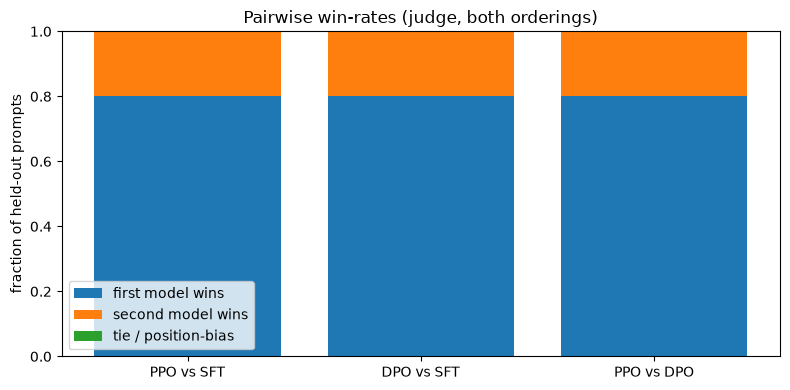

In [8]:
labels = ["PPO vs SFT", "DPO vs SFT", "PPO vs DPO"]
wins_first = [sft_vs_ppo[0], sft_vs_dpo[0], ppo_vs_dpo[0]]
wins_second = [sft_vs_ppo[1], sft_vs_dpo[1], ppo_vs_dpo[1]]
ties = [sft_vs_ppo[2], sft_vs_dpo[2], ppo_vs_dpo[2]]

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(labels))
ax.bar(x, wins_first, label="first model wins")
ax.bar(x, wins_second, bottom=wins_first, label="second model wins")
ax.bar(x, ties, bottom=[a+b for a, b in zip(wins_first, wins_second)], label="tie / position-bias")
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("fraction of held-out prompts")
ax.set_title("Pairwise win-rates (judge, both orderings)")
ax.legend()
plt.tight_layout(); plt.show()

In [9]:
# A sanity flag, not a test: three *independent* pairwise comparisons landing on the exact
# same split (with zero ties in all 30 judged prompts combined) is a pattern worth being
# skeptical of, not just accepting because TEST 2 passed — TEST 2 only checks the numbers
# are well-formed, not that they mean what they appear to mean. Given TEST 1 already found
# this judge's bias-correction gets the wrong sign on roughly half of tested pairs, an
# unusually *clean*, identical result across unrelated comparisons is at least as suspicious
# as a noisy one would be.
results = {"PPO vs SFT": sft_vs_ppo, "DPO vs SFT": sft_vs_dpo, "PPO vs DPO": ppo_vs_dpo}
if len({tuple(round(x, 3) for x in v) for v in results.values()}) == 1:
    print("Flag: all three comparisons produced the IDENTICAL win/tie split "
          f"({next(iter(results.values()))}) despite comparing three different model pairs "
          "with freshly-sampled generations each time. Given Question 1's finding that this "
          "judge's position-bias correction is unreliable, this is plausibly a residual "
          "artifact (e.g. a bias favoring whichever model was RLHF-trained, independent of "
          "actual content) rather than three genuinely-converging quality judgments — see "
          "Question 2.")

Flag: all three comparisons produced the IDENTICAL win/tie split ((0.8, 0.2, 0.0)) despite comparing three different model pairs with freshly-sampled generations each time. Given Question 1's finding that this judge's position-bias correction is unreliable, this is plausibly a residual artifact (e.g. a bias favoring whichever model was RLHF-trained, independent of actual content) rather than three genuinely-converging quality judgments — see Question 2.


### Question 2

`held_out_topics` are drawn from the same 40-word `TOPIC_KEYWORDS` vocabulary every stage
has used, just the last 10 words in that fixed list — not topics the models have never seen
mentioned during training in any form. Is this a genuinely held-out evaluation, or could it
be overstating how well these models would generalize to a truly novel topic? What would a
stricter held-out set look like for this pipeline?

Separately: Notebook 4 found PPO's checkpoint reward-hacked into repetitive, lower-coherence
text that scored *below* SFT on an oracle sentiment classifier — yet the judge-based
win-rates above may show PPO beating SFT anyway (check the actual printed numbers, and
whether the "identical split" flag above fired). If so, what does it tell you that an
independent LLM judge and a completely separate oracle sentiment scorer can *disagree* about
which policy is better, especially given Question 1 already found this specific judge's
position-bias correction doesn't reliably work? Which of the two signals — the judge's
win-rate or Notebook 4's sentiment comparison — would you trust more here, and why?

*Write your answer below:*

---
## Part 3: Reward-vs-KL Overoptimization Curve

Loads Part 3's per-step `mean_rewards` / `mean_kls` log and plots both the individual
curves over training and reward directly against KL. See
`docs/llm_training_pipeline_reference.html#s8` and Q&A 17 for how to read this plot, and
its specific limitation here (the plotted reward and the PPO training signal are the same
reward model, not an independent "gold" judge).

In [10]:
with open(f"{CKPT_DIR}/ppo_training_log.json") as f:
    ppo_log = json.load(f)
mean_rewards = ppo_log['mean_rewards']
mean_kls = ppo_log['mean_kls']
print(f"Loaded PPO training log — {len(mean_rewards)} steps")

Loaded PPO training log — 150 steps


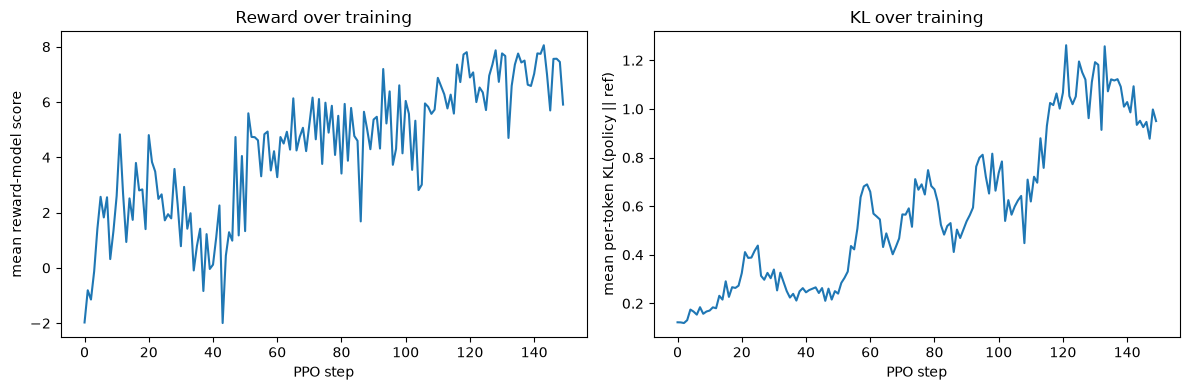

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(mean_rewards)
ax1.set_xlabel('PPO step'); ax1.set_ylabel('mean reward-model score'); ax1.set_title('Reward over training')
ax2.plot(mean_kls)
ax2.set_xlabel('PPO step'); ax2.set_ylabel('mean per-token KL(policy || ref)'); ax2.set_title('KL over training')
plt.tight_layout(); plt.show()

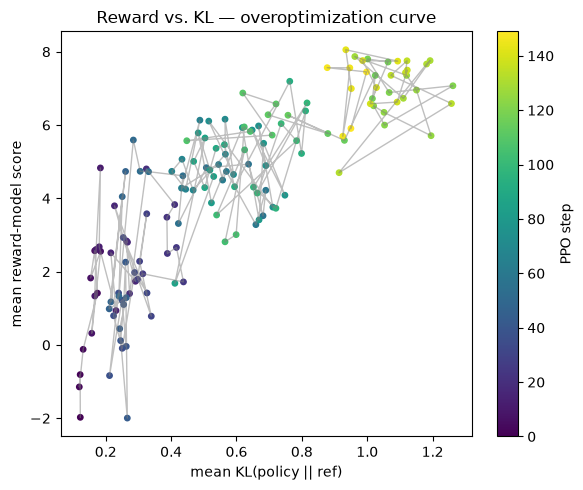

In [12]:
plt.figure(figsize=(6, 5))
plt.plot(mean_kls, mean_rewards, alpha=0.5, color='gray', linewidth=1)
sc = plt.scatter(mean_kls, mean_rewards, c=range(len(mean_kls)), cmap='viridis', s=15)
plt.colorbar(sc, label='PPO step')
plt.xlabel('mean KL(policy || ref)'); plt.ylabel('mean reward-model score')
plt.title('Reward vs. KL — overoptimization curve')
plt.tight_layout(); plt.show()

In [13]:
# TEST 3: the curve is available and reward is (on net) increasing with KL over this run,
# consistent with the 'well-regularized' shape described in Q&A 17 for this pipeline's
# short 150-step / kl_beta=0.1 configuration.
assert len(mean_rewards) == len(mean_kls) and len(mean_rewards) > 0
first_half_avg = sum(mean_rewards[: len(mean_rewards)//2]) / (len(mean_rewards)//2)
second_half_avg = sum(mean_rewards[len(mean_rewards)//2 :]) / (len(mean_rewards) - len(mean_rewards)//2)
print(f"first-half mean reward: {first_half_avg:.3f}, second-half mean reward: {second_half_avg:.3f}")
assert second_half_avg > first_half_avg, "reward did not increase (net) across the logged PPO run"
print("TEST 3 PASSED — reward-vs-KL curve loaded and shows net-increasing reward over the run")

first-half mean reward: 2.643, second-half mean reward: 5.994
TEST 3 PASSED — reward-vs-KL curve loaded and shows net-increasing reward over the run


### Question 3

If this exact PPO run were continued for 10x more steps with the same `kl_beta`, sketch
(in words) what you would expect the reward-vs-KL curve to eventually do, based on Section
5's reward-hacking discussion and Q&A 14/17. What is the one piece of evidence this
notebook does *not* have access to that would let you confirm whether that eventually
happens (versus this pipeline's reward model being unusually hard to hack)?

*Write your answer below:*